# Full Plot

Columns found: ['Time (BJD-2457000)', ' Flux', ' Flattened Flux']


,Time (BJD-2457000),Flux,Flattened Flux
0,3235.348866,1.001028,0.999057
1,3235.349329,1.001114,0.999141
2,3235.349560,1.001423,0.999449
3,3235.349792,1.001788,0.999813
4,3235.350023,1.002057,1.000080


Using time column: 'Time (BJD-2457000)' (interpreted as BJD-2457000).
Using flux column: ' Flux'. Number of points: 191904
LightCurve created:


time,flux,flux_err
,,
Time,float64,float64
3235.348865780709,1.00102768261368,nan
3235.3493287891606,1.00111385963957,nan
3235.349560293416,1.00142290191895,nan
3235.3497917976706,1.00178839504207,nan
3235.350023301867,1.00205655187267,nan


Using P = 8.956060 d
Sector/Quarter: Unknown
pgi: 0.012
A_avg: 0.401
B_avg: 0.442
Rsq_avg: 0.994
P_avg (days): 9.057
P_err (days): 0.074
HWHM_err (days): 1.415



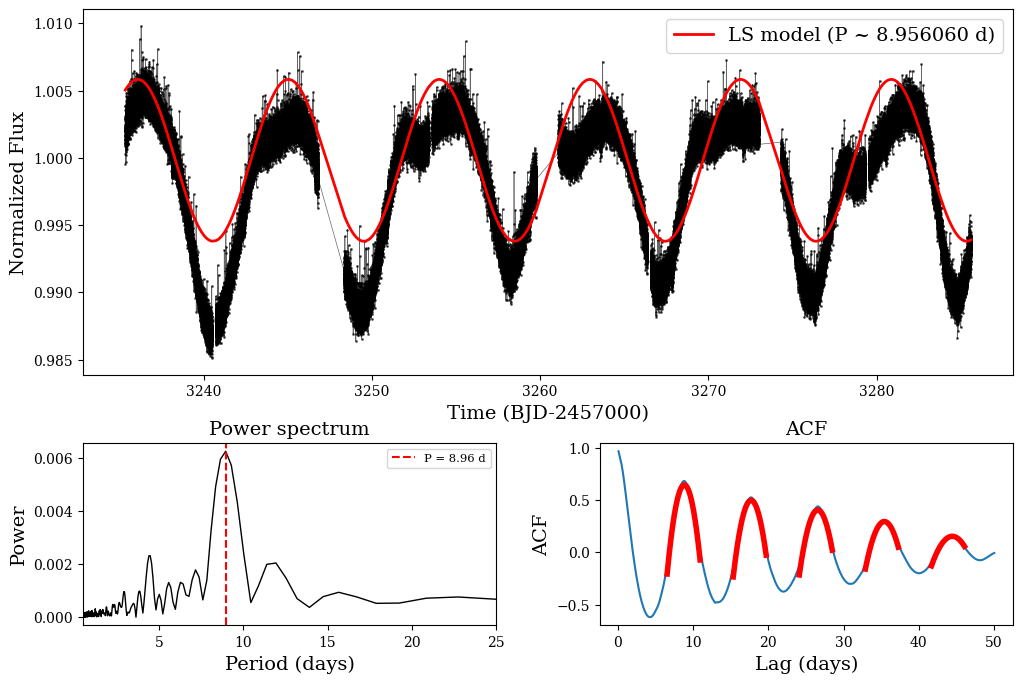

<Figure size 640x480 with 0 Axes>

In [6]:
# Combined figure using your original top-panel code exactly (LS model plotted via lc_model.plot)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import astropy.units as u
from astropy.time import Time
import SpinSpotter as ss
import matplotlib.gridspec as gridspec
import matplotlib as mpl

# === APPEARANCE SETTINGS (edit these) ===
FONT_FAMILY = "serif"        # e.g., 'serif', 'sans-serif', 'DejaVu Serif', 'Times New Roman'
TITLE_FONT_SIZE = 14         # title font size (pts)
LABEL_FONT_SIZE = 14         # axis label font size (pts)
TOP_TICK_SIZE = 10            # tick label size for top panel (pts)
BOTTOM_TICK_SIZE = 10        # tick label size for bottom panels (pts)

# Apply global font family
plt.rcParams["font.family"] = FONT_FAMILY

# === PARAMETERS (edit only the DATA_PATH if you need) ===
long_dataset = False
# long_dataset = True
if long_dataset:
    DATA_PATH = "./data/tic437011608flattened-2min.csv"
else:
    DATA_PATH = "./data/tic437011608flattened-20s.csv"
min_period = 0.5
max_period = 25.0
# min_period = 7.75
# max_period = 10
bs = 1000  # SpinSpotter box size

# ---------------------------------------
# 1) Top-panel data & LS model (exact code you provided)
# ---------------------------------------
df = pd.read_csv(DATA_PATH)
print('Columns found:', df.columns.tolist())
display(df.head())

# Detect time column (auto-detect based on 'time' or 'bjd')
time_col_candidates = [c for c in df.columns if 'time' in c.lower() or 'bjd' in c.lower()]
time_col = time_col_candidates[0] if time_col_candidates else df.columns[0]

# Force use of the 'Flux' column (2nd column) instead of Flattened Flux
if 'Flux' in df.columns:
    flux_col = 'Flux'
else:
    flux_col = df.columns[1]  # fallback to second column

# Parse arrays
time_rel = df[time_col].values.astype(float)   # your files use BJD-2457000 per header
time_bjd = time_rel + 2457000.0
flux = df[flux_col].values.astype(float)

print(f"Using time column: '{time_col}' (interpreted as BJD-2457000).")
print(f"Using flux column: '{flux_col}'. Number of points: {len(time_rel)}")

# Create a Lightkurve LightCurve object (time in days is OK)
lc = lk.LightCurve(time=time_rel, flux=flux)
print('LightCurve created:')
display(lc.head())

# Keep numeric arrays handy
time = time_rel

# ===== Lomb-Scargle periodogram via Lightkurve convenience (diagnostic) =====
pg_ls = lc.to_periodogram(method='lombscargle', minimum_period=min_period, maximum_period=max_period)
# Make sure we have numeric arrays for the power spectrum later
try:
    period_arr = pg_ls.period.to_value("day")
except Exception:
    period_arr = np.asarray(pg_ls.period)
power_arr = np.asarray(pg_ls.power)

ax_tmp = pg_ls.plot(view='period')  # optional quick diagnostic (this may open a figure)
plt.close()  # close the diagnostic automatic figure if any

# Extract best period and frequency
P = pg_ls.period_at_max_power.to_value("day")
f = pg_ls.frequency_at_max_power
print(f"Using P = {P:.6f} d")

# Build the sinusoidal model light curve (returns a LightCurve object)
# Use lc.time exactly as in your code
try:
    lc_model = pg_ls.model(lc.time, frequency=f)
except Exception:
    # fallback if that signature fails
    lc_model = pg_ls.model(lc.time.value, frequency=f)

# ---------------------------------------
# 2) SpinSpotter processing for ACF (same as you used)
# ---------------------------------------
fits_result, process_result = ss.process_LightCurve(lc, bs=bs)
# optional text summary (keeps behavior same as before)
ss.print_summary(fits_result, process_result, bs=bs)

# ---------------------------------------
# 3) Build combined figure with three panels
# ---------------------------------------
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], hspace=0.25, wspace=0.25)

# Top: full light curve with LS model spanning both columns
ax_top = fig.add_subplot(gs[0, :])

# Use Lightkurve plotting into our axes — replicate your snippet:
# Note: your snippet used lc.plot() and lc_model.plot(), so use same here and pass ax=...
try:
    lc.plot(ax=ax_top, marker='.', markersize=2, alpha=0.6, color='k')   # exactly as your snippet
except Exception:
    # Fallback: manual plotting preserving same visual style
    ax_top.plot(time, flux, '.', markersize=2, alpha=0.6, color='k')

# Overlay model exactly as in your snippet:
try:
    # lc_model might be a LightCurve object (preferred)
    lc_model.plot(ax=ax_top, lw=2, c='red', label=f'LS model (P ~ {P:.6f} d)')
except Exception:
    # If lc_model is an array aligned with lc.time, plot that
    try:
        model_arr = np.asarray(lc_model)
        if model_arr.shape == lc.time.value.shape:
            ax_top.plot(lc.time.value, model_arr, '-', color='red', lw=2, label=f'LS model (P ~ {P:.6f} d)')
        else:
            # If model has time attribute, use it
            if hasattr(lc_model, 'time') and hasattr(lc_model, 'flux'):
                try:
                    tplot = np.asarray(lc_model.time.value)
                    fplot = np.asarray(lc_model.flux)
                    ax_top.plot(tplot, fplot, '-', color='red', lw=2, label=f'LS model (P ~ {P:.6f} d)')
                except Exception:
                    pass
    except Exception:
        pass

# Apply title/label font sizes and top tick size
# ax_top.set_title(f'Full light curve with LS model (P ~ {P:.6f} d)', fontsize=TITLE_FONT_SIZE)
ax_top.set_xlabel('Time (BJD-2457000)', fontsize=LABEL_FONT_SIZE)
ax_top.set_ylabel('Normalized Flux', fontsize=LABEL_FONT_SIZE)
ax_top.tick_params(axis='both', which='major', labelsize=TOP_TICK_SIZE)

ax_top.legend(fontsize=LABEL_FONT_SIZE)
# ax_top.set_title(f'Full light curve with LS model (P ~ {P:.6f} d)')
# ax_top.set_xlabel('Time (BJD-2457000)')
# ax_top.set_ylabel('Normalized Flux')

# Bottom-left: power spectrum (period on x-axis)
ax_bl = fig.add_subplot(gs[1, 0])
ax_bl.plot(period_arr, power_arr, '-', color='k', lw=1)
ax_bl.axvline(P, color='r', linestyle='--', label=f'P = {P:.2f} d')
ax_bl.set_xlabel('Period (days)', fontsize=LABEL_FONT_SIZE)
ax_bl.set_ylabel('Power', fontsize=LABEL_FONT_SIZE)
ax_bl.set_title('Power spectrum', fontsize=TITLE_FONT_SIZE)
ax_bl.set_xlim(min_period, max(10, max_period))
ax_bl.legend(fontsize='small')
ax_bl.tick_params(axis='both', which='major', labelsize=BOTTOM_TICK_SIZE)

# Bottom-right: ACF via SpinSpotter (draw into this axis)
ax_br = fig.add_subplot(gs[1, 1])

# Strategy: make a temporary figure for spinspotter ACF and copy artists into our axis
import matplotlib.pyplot as mpl

# Create temp figure and call ss.plot_acf; copy artists from its axes to ax_br
fig_tmp = mpl.figure()
try:
    ss.plot_acf(fits_result, process_result, plot_peaks=True)
    fig_acf = mpl.gcf()
    # find the source axis (usually the first axis)
    if len(fig_acf.axes) > 0:
        ax_src = fig_acf.axes[0]
        # copy lines
        for line in ax_src.get_lines():
            ax_br.plot(line.get_xdata(), line.get_ydata(),
                        linestyle=line.get_linestyle(), marker=line.get_marker(),
                        color=line.get_color(), lw=line.get_linewidth(), label=line.get_label())
        # copy collections (scatter points)
        for coll in ax_src.collections:
            offsets = coll.get_offsets()
            if offsets is not None and len(offsets) > 0:
                ax_br.scatter(offsets[:,0], offsets[:,1],
                              s=getattr(coll, "_sizes", [10])[0],
                              c=coll.get_facecolor(), alpha=coll.get_alpha())
        # copy labels
        ax_br.set_xlabel(ax_src.get_xlabel(), fontsize=LABEL_FONT_SIZE)
        ax_br.set_ylabel(ax_src.get_ylabel(), fontsize=LABEL_FONT_SIZE)
        # ax_br.set_xlim(4.75, 13)
        ax_br.set_title('ACF', fontsize=TITLE_FONT_SIZE)
    else:
        # fallback: compute ACF manually if no axes found
        from statsmodels.tsa.stattools import acf
        acf_vals = acf(lc.flux.value - np.nanmean(lc.flux.value), nlags=200, fft=True, missing='conservative')
        lags = np.arange(len(acf_vals)) * np.median(np.diff(lc.time.value))
        ax_br.plot(lags, acf_vals, '-k')
        ax_br.set_xlabel('Lag [days]', fontsize=LABEL_FONT_SIZE)
        ax_br.set_ylabel('ACF', fontsize=LABEL_FONT_SIZE)
        ax_br.set_title('Autocorrelation (fallback)', fontsize=TITLE_FONT_SIZE)
finally:
    try:
        mpl.close(fig_acf)
    except Exception:
        pass

ax_br.tick_params(axis='both', which='major', labelsize=BOTTOM_TICK_SIZE)

plt.tight_layout()
if long_dataset:
    plt.savefig("./plots/full_periodogram_2min.pdf", dpi=300, bbox_inches='tight')
else:
    plt.savefig("./plots/full_periodogram_20s.pdf", bbox_inches='tight')#, dpi=300)
plt.show()


# Diagnostics

In [ ]:
# Diagnostic: find real local LS peaks and local ACF peaks (matches your pipeline calls)
# Run this AFTER the code that created `lc`, `pg_ls`, and `fits_result/process_result`.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import find_peaks
import warnings

# ---------- USER-TUNABLE PARAMETERS ----------
N_LS_TO_PRINT = 6            # how many LS candidate peaks to list
MIN_SEPARATION_DAYS = 0.8    # min separation between distinct LS peaks (days) (tune as e.g. 0.5-1d)
LS_PROMINENCE = None         # if set, require this prominence; else compute adaptive
MIN_LAG_DAYS = 0.3           # ignore ACF peaks with lag < this (days); prevents cadence-scale picks
ACF_PROMINENCE = 0.02        # min prominence for ACF peaks (tune down if too strict)
# --------------------------------------------

# Sanity checks
if 'pg_ls' not in globals():
    raise RuntimeError("pg_ls not found. Run the LS periodogram cell first (your combined cell).")
if 'fits_result' not in globals() or 'process_result' not in globals():
    raise RuntimeError("SpinSpotter outputs not found. Run ss.process_LightCurve(...) first (your combined cell).")

# --- 1) Extract periodogram arrays from pg_ls exactly as your pipeline does ---
try:
    period_arr = pg_ls.period.to_value("day")  # numeric array of periods (days)
except Exception:
    period_arr = np.asarray(pg_ls.period)
power_arr = np.asarray(pg_ls.power)

# Ensure arrays are 1D and sorted in increasing period (Lightkurve usually gives ascending period)
period_arr = np.asarray(period_arr).ravel()
power_arr = np.asarray(power_arr).ravel()
if period_arr.size != power_arr.size:
    raise RuntimeError("period and power arrays have different sizes.")

# Compute median period spacing -> use to convert MIN_SEPARATION_DAYS -> idx distance
pdiff = np.diff(period_arr)
median_pstep = np.median(np.abs(pdiff)) if pdiff.size>0 else 1.0
idx_distance = max(1, int(np.round(MIN_SEPARATION_DAYS / (median_pstep if median_pstep>0 else 1.0))))

# Adaptive LS prominence if not supplied: use fraction of dynamic range
if LS_PROMINENCE is None:
    LS_PROMINENCE = max(1e-4, 0.05 * (np.nanmax(power_arr) - np.nanmin(power_arr)))

# Find local peaks in the LS power spectrum
peaks_ls, props_ls = find_peaks(power_arr, prominence=LS_PROMINENCE, distance=idx_distance)
# Sort peaks by power descending
order_ls = np.argsort(power_arr[peaks_ls])[::-1]

print("\nLomb-Scargle: found", len(peaks_ls), "local peaks (after min separation & prominence).")
print("Top LS candidates (period [d], power, prominence):")
for i in range(min(N_LS_TO_PRINT, len(order_ls))):
    pk = peaks_ls[order_ls[i]]
    print(f"  {i+1:2d}: {period_arr[pk]:8.4f} d    power={power_arr[pk]:8.4g}   prom={props_ls['prominences'][order_ls[i]]:8.4g}")

# Report LS period_at_max_power for reference
try:
    P_report = pg_ls.period_at_max_power.to_value("day")
    print(f"LS period_at_max_power (Lightkurve convenience): {P_report:.6f} d")
except Exception:
    pass

# --- 2) Capture the ACF curve exactly as produced by your SpinSpotter call,
#         by calling ss.plot_acf(...) into a temporary figure and extracting plotted lines.
fig_temp = plt.figure()
ss.plot_acf(fits_result, process_result, plot_peaks=True)   # exactly your call
fig_acf = plt.gcf()

# Try to find the ACF curve in the created figure
acf_x = None
acf_y = None
if len(fig_acf.axes) > 0:
    ax_src = fig_acf.axes[0]
    # prefer the first line (often main ACF)
    lines = ax_src.get_lines()
    if len(lines) > 0:
        # choose the longest line (the actual ACF x,y)
        lengths = [len(l.get_xdata()) for l in lines]
        idx_long = int(np.argmax(lengths))
        acf_x = np.asarray(lines[idx_long].get_xdata())
        acf_y = np.asarray(lines[idx_long].get_ydata())
    else:
        # maybe the ACF was plotted as a collection (rare) - try to get first collection's offsets
        if len(ax_src.collections) > 0:
            coll = ax_src.collections[0]
            offsets = coll.get_offsets()
            if offsets is not None and offsets.shape[1] >= 2:
                acf_x = np.asarray(offsets[:,0])
                acf_y = np.asarray(offsets[:,1])

# close the temp figure to avoid dup windows
try:
    plt.close(fig_acf)
except Exception:
    pass

if acf_x is None or acf_y is None:
    raise RuntimeError("Could not extract ACF curve from SpinSpotter's plot. Verify ss.plot_acf's output shape.")

# Ensure ACF uses days for lag axis; if SpinSpotter used indices, try to detect and convert
# Heuristic: if acf_x max is small (<< 1 day) but your timespan is many days, SpinSpotter might be using
# units of days already (fine) or fraction-of-day — we'll assume acf_x is in days as SpinSpotter normally does.
# Print a little summary:
print("\nExtracted ACF curve: x range:", acf_x.min(), "to", acf_x.max(), "(units assumed days)")

# Filter out tiny-lag peaks (cadence/noise)
valid_idx = acf_x >= MIN_LAG_DAYS
if np.count_nonzero(valid_idx) == 0:
    warnings.warn("All ACF x-values are < MIN_LAG_DAYS; lowering MIN_LAG_DAYS might be necessary.")
    valid_idx = np.ones_like(acf_x, dtype=bool)

acf_x_filt = acf_x[valid_idx]
acf_y_filt = acf_y[valid_idx]

# Find peaks in ACF (local maxima) with prominence
# adjust ACF_PROMINENCE to a small fraction of dynamic range
acf_prom = ACF_PROMINENCE if ACF_PROMINENCE is not None else 0.02 * (np.nanmax(acf_y_filt)-np.nanmin(acf_y_filt))
peaks_acf, props_acf = find_peaks(acf_y_filt, prominence=acf_prom)
# Map peaks back to original lag values
peaks_acf_lags = acf_x_filt[peaks_acf]
peaks_acf_vals = acf_y_filt[peaks_acf]

# sort acf peaks by acf height descending
order_acf = np.argsort(peaks_acf_vals)[::-1]
print("\nACF: found", len(peaks_acf), "peaks (lag >= %.2f d)." % MIN_LAG_DAYS)
print("Top ACF candidate lags (days) and acf-values:")
for i in range(min(6, len(order_acf))):
    j = order_acf[i]
    print(f"  {i+1:2d}: lag = {peaks_acf_lags[j]:8.4f} d   acf = {peaks_acf_vals[j]:8.4f}   prom={props_acf['prominences'][j]:8.4g}")

# --- 3) Plots for visual check: LS with found peaks, ACF with found peaks, and two fold plots
fig, axes = plt.subplots(2, 2, figsize=(12,8), gridspec_kw={'height_ratios':[1,1]})
ax_ls = axes[0,0]; ax_acf = axes[0,1]; ax_fold_ls = axes[1,0]; ax_fold_acf = axes[1,1]

# LS power vs period (annotate found local peaks)
ax_ls.plot(period_arr, power_arr, '-', color='k')
for p_idx in peaks_ls:
    ax_ls.plot(period_arr[p_idx], power_arr[p_idx], 'o', color='red')
# label top N
for i in range(min(N_LS_TO_PRINT, len(order_ls))):
    pk = peaks_ls[order_ls[i]]
    ax_ls.text(period_arr[pk], power_arr[pk]+0.00002, f"{period_arr[pk]:.3f}d", color='red', fontsize=8)
ax_ls.set_xlabel("Period [days]"); ax_ls.set_ylabel("Power"); ax_ls.set_title("LS power (local peaks shown)")
ax_ls.set_xlim(min(period_arr), max(period_arr))

# ACF curve and peaks (we plotted after MIN_LAG_DAYS cutoff)
ax_acf.plot(acf_x, acf_y, '-k', label='acf (full)')
ax_acf.plot(acf_x_filt, acf_y_filt, '-', color='0.4')
if len(peaks_acf) > 0:
    ax_acf.plot(peaks_acf_lags, peaks_acf_vals, 'o', color='red')
    for i in range(min(6, len(order_acf))):
        j = order_acf[i]
        ax_acf.text(peaks_acf_lags[j]-0.025, peaks_acf_vals[j]+0.05, f"{peaks_acf_lags[j]:.3f}d", color='red', fontsize=8)
ax_acf.set_xlabel("Lag [days]"); ax_acf.set_ylabel("ACF"); ax_acf.set_title("ACF (extracted from SpinSpotter)")

# fold on top LS and top ACF candidates
if len(order_ls)>0:
    top_ls_period = period_arr[peaks_ls[order_ls[0]]]
else:
    top_ls_period = None
top_acf_lag = peaks_acf_lags[order_acf[0]] if len(order_acf)>0 else None

def fold_plot(ax, period, title):
    if period is None:
        ax.text(0.5,0.5,"No period", ha='center')
        return
    phases = ((lc.time.value - lc.time.value[0]) % period) / period
    idxs = np.argsort(phases)
    ax.plot(phases[idxs], lc.flux.value[idxs], '.', ms=2, alpha=0.6)
    # binned medians
    nbins = 60
    bins = np.linspace(0,1,nbins+1)
    digit = np.digitize(phases, bins)
    med = [np.nanmedian(lc.flux.value[digit==i]) if np.any(digit==i) else np.nan for i in range(1,len(bins))]
    centers = 0.5*(bins[:-1]+bins[1:])
    ax.plot(centers, med, '-r', lw=1)
    ax.set_xlabel("Phase"); ax.set_ylabel("Flux"); ax.set_title(title)

fold_plot(ax_fold_ls, top_ls_period, f"Folded on LS top = {top_ls_period:.4f} d" if top_ls_period else "No LS top")
fold_plot(ax_fold_acf, top_acf_lag, f"Folded on ACF top = {top_acf_lag:.4f} d" if top_acf_lag else "No ACF top")

plt.tight_layout()
plt.show()

# --- 4) Quick harmonic check between top LS and top ACF
def find_simple_ratio(a, b, tol=0.05):
    if a is None or b is None: return None
    for n in range(1,6):
        if abs(a - n*b)/b < tol: return f"a ~ {n}*b"
        if abs(b - n*a)/a < tol: return f"b ~ {n}*a"
    return None

harm = find_simple_ratio(top_ls_period, top_acf_lag)
print("\nHarmonic check (top LS vs top ACF):", harm if harm else "no simple harmonic within 5%")
